In [1]:
import sys
from collections import defaultdict
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem import PandasTools
import pandas as pd
import py3Dmol
IPythonConsole.ipython_3d=True

%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt

In [2]:
# Suppress RDKit warnings
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

# File paths
# The input ligand structure (COC_ideal.sdf) was downloaded from RCSB:
# https://www.rcsb.org/ligand/COC
sdfFilePath = 'COC_ideal.sdf'          # Input file for generating conformations
ConfoutputFilePath = 'ForDockingConfs.sdf'  # Output file containing conformations for docking

# Load molecules from the SDF file (retain hydrogens)
inputMols = [mol for mol in Chem.SDMolSupplier(sdfFilePath, removeHs=False)]

# Check how many structures were loaded
len(inputMols)

1

In [3]:
#Check that all molecules have a name
for i, mol in enumerate(inputMols):
    if mol is None:
        print('Warning: Failed to read molecule %s in %s' % (i, sdfFilePath))
    if not mol.GetProp('_Name'):

        print('Warning: No name for molecule %s in %s' % (i, sdfFilePath))


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

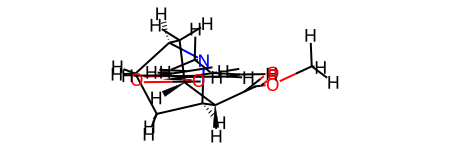

In [4]:
#option to view individual structures (comment out with # if not needed)
mol = inputMols[0]
mol

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

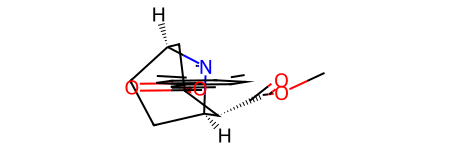

In [5]:
mol_noH = Chem.RemoveHs(mol)                  # remove hydrogens
mol_noH

## Conformation generation
From RDKit documentation. Disclaimer/Warning: Conformer generation is a difficult and subtle task.

The docking program SMINA will rotate around torsions which may be enough for some molecules, however it will not flip rings and probably not identify cis amides. For some molecules you may not need to do conformation generation (set numConfs = 1).



In [6]:
#edit numConfs to desired number
with Chem.SDWriter(ConfoutputFilePath) as w:
    for mol in inputMols:
        m = Chem.AddHs(mol)
        cids = AllChem.EmbedMultipleConfs(m, numConfs=3, numThreads=0) #edit num confs
        confs = m.GetConformers()
        for c in confs:
            w.write(m, confId=c.GetId())

In [7]:
ms = [x for x in Chem.SDMolSupplier(ConfoutputFilePath,removeHs=False)]
# Assign atomic chirality based on the structures:
for m in ms: Chem.AssignAtomChiralTagsFromStructure(m)
len(ms) # check how many conformations

3

## Docking cocaine to hDAT

In [8]:
%%bash
if [ ! -f "smina.osx.12" ]; then
    echo "smina.osx.12 not found, downloading..."
    wget https://sourceforge.net/projects/smina/files/smina.osx.12/download -O smina.osx.12
    chmod u+x smina.osx.12
    xattr -d com.apple.quarantine smina.osx.12
else
    echo "smina.osx.12 already exists."
fi

./smina.osx.12 --help

smina.osx.12 already exists.

Input:
  -r [ --receptor ] arg         rigid part of the receptor
  --flex arg                    flexible side chains, if any
  -l [ --ligand ] arg           ligand(s)
  --flexres arg                 flexible side chains specified by comma 
                                separated list of chain:resid or 
                                chain:resid:icode
  --flexdist_ligand arg         Ligand to use for flexdist
  --flexdist arg                set all side chains within specified distance 
                                to flexdist_ligand to flexible

Search space (required):
  --center_x arg                X coordinate of the center
  --center_y arg                Y coordinate of the center
  --center_z arg                Z coordinate of the center
  --size_x arg                  size in the X dimension (Angstroms)
  --size_y arg                  size in the Y dimension (Angstroms)
  --size_z arg                  size in the Z dimension (Angstroms)
  --

In [9]:
ProteinForDocking = '9EO4_prot.pdb'
LigandFromProtein = '9EO4_COC.pdb'
DockedFilePath = 'My_Docked.sdf'
FlexibleDockedFilePath = 'FlexDocked.sdf.gz'

In [10]:
!'./smina.osx.12' --exhaustiveness 20 --cpu 10 --seed 0 --autobox_ligand '{LigandFromProtein}' -r '{ProteinForDocking}' -l '{ConfoutputFilePath}' -o '{DockedFilePath}'

   _______  _______ _________ _        _______ 
  (  ____ \(       )\__   __/( (    /|(  ___  )
  | (    \/| () () |   ) (   |  \  ( || (   ) |
  | (_____ | || || |   | |   |   \ | || (___) |
  (_____  )| |(_)| |   | |   | (\ \) ||  ___  |
        ) || |   | |   | |   | | \   || (   ) |
  /\____) || )   ( |___) (___| )  \  || )   ( |
  \_______)|/     \|\_______/|/    )_)|/     \|


smina is based off AutoDock Vina. Please cite appropriately.

Weights      Terms
-0.035579    gauss(o=0,_w=0.5,_c=8)
-0.005156    gauss(o=3,_w=2,_c=8)
0.840245     repulsion(o=0,_c=8)
-0.035069    hydrophobic(g=0.5,_b=1.5,_c=8)
-0.587439    non_dir_h_bond(g=-0.7,_b=0,_c=8)
1.923        num_tors_div

Using random seed: 0

0%   10   20   30   40   50   60   70   80   90   100%
|----|----|----|----|----|----|----|----|----|----|
***************************************************

mode |   affinity | dist from best mode
     | (kcal/mol) | rmsd l.b.| rmsd u.b.
-----+------------+----------+----------
1       -

# Visualization of docking poses

In [11]:
import py3Dmol

v = py3Dmol.view()

# Load protein
v.addModel(open('9EO4_prot.pdb').read())
v.setStyle({'model':0},{
    'cartoon':{'opacity':0.6},
    'stick':{'radius':0.02,'opacity':0.2}
})

# Highlight residue D79
v.setStyle({'model':0,'resi':79,'chain':'B'},
           {'stick':{'radius':0.25,'colorscheme':'cyanCarbon','opacity':1.0}})

# Load ligand
v.addModel(open('9EO4_COC.pdb').read())
v.setStyle({'model':1},{'stick':{'colorscheme':'redCarbon','radius':0.125}})

# Load docked poses
v.addModelsAsFrames(open('My_Docked.sdf','rt').read())
v.setStyle({'model':2},{'stick':{'colorscheme':'greenCarbon'}})

# Animate and center
v.animate({'interval':1000})
v.zoomTo({'model':2})
v.rotate(90)

# Switch to orthographic projection
v.setProjection("orthographic")

v.show()


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

Residue D79 is highlighted in cyan, while the crystallographic cocaine ligand is shown in red. The crystal structure of human dopamine transporter (PDB ID: 9EO4) reveals that cocaine forms a hydrogen bond with the nitrogen atom of the ligand (Nielsen JC, Salomon K, Kalenderoglou IE, Bargmeyer S, Pape T, Shahsavar A, Loland CJ. Nature 2024, doi:10.1038/s41586-024-07804-3). The docking poses generated by Smina successfully reproduce this binding mode, demonstrating consistency between computational predictions and the crystallographic data.